# 03 - Hypothesis Testing

In this notebook, the hypotheses proposed in the project are tested statistically using the Spotify track datasets.

## Main Research Question

Which audio features significantly distinguish high-popularity Spotify songs from low-popularity Spotify songs?

## Sub-Questions

1. Are high-popularity songs generally more energetic and louder than low-popularity songs?
2. Are high-popularity songs more danceable and emotionally positive?
3. Are high-popularity songs less acoustic and less instrumental than low-popularity songs?

## Hypotheses

- **H1:** High-popularity songs have significantly higher **energy** and **loudness** values than low-popularity songs.
- **H2:** High-popularity songs have significantly higher **danceability** and **valence** values than low-popularity songs.
- **H3:** High-popularity songs have significantly lower **acousticness** and **instrumentalness** values than low-popularity songs.
- **H0 (Null Hypothesis):** There is no statistically significant difference between high-popularity and low-popularity songs in terms of these selected audio features.

## Statistical Testing Strategy

Since the two groups are independent and have different sample sizes, **Welch’s t-test** is used instead of the standard independent t-test.  
Welch’s t-test is more appropriate when group variances and sample sizes may differ.

In addition to p-values, this notebook also reports:

- **Mean differences**
- **95% confidence intervals**
- **Cohen’s d effect size**
- **Bonferroni-corrected p-values** for multiple testing control


In [2]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SEARCH_DIRS = [".", "/mnt/data"]

def load_csv(possible_names):
    for directory in SEARCH_DIRS:
        for name in possible_names:
            path = os.path.join(directory, name)
            if os.path.exists(path):
                return pd.read_csv(path), path
    raise FileNotFoundError(f"Could not find any of these files in {SEARCH_DIRS}: {possible_names}")

high, high_file = load_csv([
    "high_popularity_spotify_data.csv",
    "high_popularity_spotify_data(1).csv"
])

low, low_file = load_csv([
    "low_popularity_spotify_data.csv",
    "low_popularity_spotify_data(1).csv"
])

print("Loaded files:")
print("High popularity dataset:", high_file)
print("Low popularity dataset :", low_file)
print()
print("High shape:", high.shape)
print("Low shape :", low.shape)

Loaded files:
High popularity dataset: ./high_popularity_spotify_data.csv
Low popularity dataset : ./low_popularity_spotify_data.csv

High shape: (1686, 29)
Low shape : (3145, 29)


## Selected Features for Hypothesis Testing

The following six features are directly tied to the main hypotheses:

- `energy`
- `loudness`
- `danceability`
- `valence`
- `acousticness`
- `instrumentalness`

These features were chosen based on:
1. the project proposal,
2. the exploratory data analysis,
3. and the strength of the observed differences between the two popularity groups.


In [3]:
features = [
    "energy",
    "loudness",
    "danceability",
    "valence",
    "acousticness",
    "instrumentalness"
]

print("Selected features:")
for f in features:
    print("-", f)

print("\nMissing values in selected features (high):")
print(high[features].isnull().sum())

print("\nMissing values in selected features (low):")
print(low[features].isnull().sum())

Selected features:
- energy
- loudness
- danceability
- valence
- acousticness
- instrumentalness

Missing values in selected features (high):
energy              0
loudness            0
danceability        0
valence             0
acousticness        0
instrumentalness    0
dtype: int64

Missing values in selected features (low):
energy              1
loudness            1
danceability        1
valence             1
acousticness        1
instrumentalness    1
dtype: int64


## Group Summary Statistics

Before hypothesis testing, it is useful to compare the average feature values in the two groups.


In [4]:
summary = pd.DataFrame({
    "high_mean": high[features].mean(),
    "low_mean": low[features].mean(),
    "high_std": high[features].std(),
    "low_std": low[features].std(),
    "mean_difference": high[features].mean() - low[features].mean()
}).sort_values("mean_difference", ascending=False)

summary

,high_mean,low_mean,high_std,low_std,mean_difference
loudness,-6.704131,-10.663833,3.377068,8.155066,3.959702
energy,0.667216,0.543509,0.184908,0.263635,0.123707
valence,0.525737,0.458438,0.236113,0.266140,0.067299
danceability,0.650362,0.607268,0.157721,0.200372,0.043093
acousticness,0.221220,0.405567,0.250593,0.342249,-0.184347
instrumentalness,0.041520,0.286603,0.156556,0.395181,-0.245083


## Welch's t-test Function

The helper function below computes:

- Welch's t-test
- p-value
- mean difference
- Welch-style 95% confidence interval
- Cohen's d effect size


In [6]:
def welch_test_with_effect_size(high_series, low_series):
    x1 = high_series.dropna().astype(float)
    x2 = low_series.dropna().astype(float)

    n1, n2 = len(x1), len(x2)
    mean1, mean2 = x1.mean(), x2.mean()
    var1, var2 = x1.var(ddof=1), x2.var(ddof=1)

    # Welch t-test
    t_stat, p_value = stats.ttest_ind(x1, x2, equal_var=False)

    # Mean difference
    mean_diff = mean1 - mean2

    # Standard error for Welch CI
    se = math.sqrt(var1 / n1 + var2 / n2)

    # Welch-Satterthwaite degrees of freedom
    numerator = (var1 / n1 + var2 / n2) ** 2
    denominator = ((var1 / n1) ** 2) / (n1 - 1) + ((var2 / n2) ** 2) / (n2 - 1)
    df = numerator / denominator

    # 95% confidence interval
    t_crit = stats.t.ppf(0.975, df)
    ci_low = mean_diff - t_crit * se
    ci_high = mean_diff + t_crit * se

    # Cohen's d using pooled SD
    pooled_sd = math.sqrt(
        (((n1 - 1) * x1.std(ddof=1) ** 2) + ((n2 - 1) * x2.std(ddof=1) ** 2)) / (n1 + n2 - 2)
    )
    cohen_d = mean_diff / pooled_sd

    return {
        "high_mean": mean1,
        "low_mean": mean2,
        "mean_diff": mean_diff,
        "t_stat": t_stat,
        "p_value": p_value,
        "df": df,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "cohen_d": cohen_d
    }

## Running the Hypothesis Tests

The significance level is set to **0.05**.

Because six related hypothesis tests are performed, **Bonferroni correction** is also reported:

\[
\alpha_{corrected} = \frac{0.05}{6}
\]

This helps reduce the risk of false positives caused by multiple comparisons.


In [7]:
results = []

for feature in features:
    result = welch_test_with_effect_size(high[feature], low[feature])
    result["feature"] = feature
    results.append(result)

results_df = pd.DataFrame(results)

# Bonferroni correction
m = len(features)
results_df["bonferroni_p"] = (results_df["p_value"] * m).clip(upper=1.0)
results_df["reject_H0_0_05"] = results_df["p_value"] < 0.05
results_df["reject_H0_bonferroni"] = results_df["bonferroni_p"] < 0.05

def interpret_effect_size(d):
    ad = abs(d)
    if ad < 0.2:
        return "very small"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    else:
        return "large"

results_df["effect_size_interpretation"] = results_df["cohen_d"].apply(interpret_effect_size)

results_df = results_df[
    [
        "feature",
        "high_mean",
        "low_mean",
        "mean_diff",
        "ci_low",
        "ci_high",
        "t_stat",
        "df",
        "p_value",
        "bonferroni_p",
        "cohen_d",
        "effect_size_interpretation",
        "reject_H0_0_05",
        "reject_H0_bonferroni"
    ]
].sort_values("p_value")

results_df

,feature,high_mean,low_mean,mean_diff,ci_low,ci_high,t_stat,df,p_value,bonferroni_p,cohen_d,effect_size_interpretation,reject_H0_0_05,reject_H0_bonferroni
5,instrumentalness,0.041520,0.286603,-0.245083,-0.260792,-0.229373,-30.585487,4528.411038,6.283194e-187,3.769917e-186,-0.738220,medium,True,True
1,loudness,-6.704131,-10.663833,3.959702,3.632136,4.287269,23.698766,4597.581270,3.074157e-117,1.844494e-116,0.575901,medium,True,True
4,acousticness,0.221220,0.405567,-0.184347,-0.201269,-0.167425,-21.357525,4388.076084,2.288793e-96,1.373276e-95,-0.588364,medium,True,True
0,energy,0.667216,0.543509,0.123707,0.110944,0.136471,19.001343,4496.426723,1.683490e-77,1.010094e-76,0.517341,medium,True,True
3,valence,0.525737,0.458438,0.067299,0.052680,0.081917,9.025901,3814.059554,2.765713e-19,1.659428e-18,0.262824,small,True,True
2,danceability,0.650362,0.607268,0.043093,0.032808,0.053379,8.213942,4183.765664,2.823751e-16,1.694250e-15,0.230944,small,True,True


## Visual Comparison of Group Means

The following chart shows the average value of each tested feature for high-popularity and low-popularity songs.


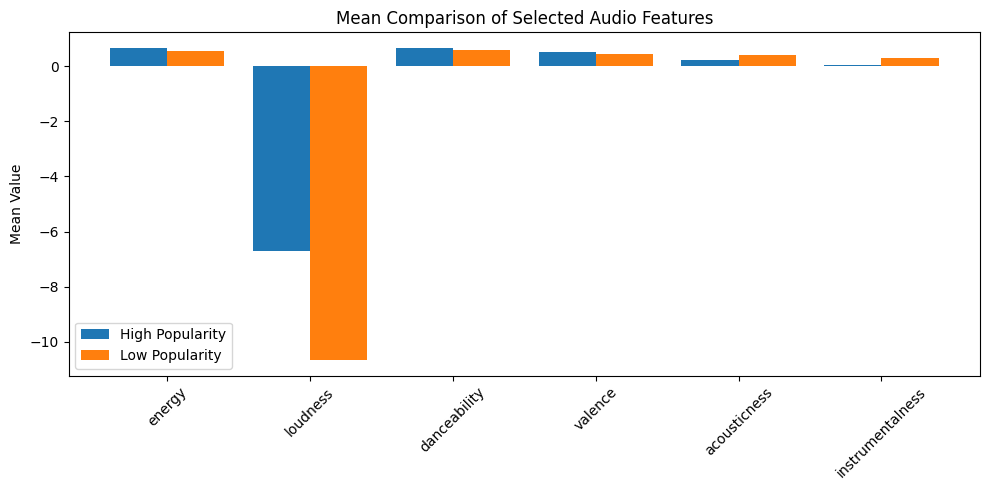

In [8]:
high_means = [high[f].mean() for f in features]
low_means = [low[f].mean() for f in features]

x = np.arange(len(features))
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, high_means, width=width, label="High Popularity")
plt.bar(x + width/2, low_means, width=width, label="Low Popularity")
plt.xticks(x, features, rotation=45)
plt.ylabel("Mean Value")
plt.title("Mean Comparison of Selected Audio Features")
plt.legend()
plt.tight_layout()
plt.show()

## Distribution Comparison

Boxplots are useful to compare the spread and central tendency of the selected features across the two groups.


/tmp/ipykernel_37295/1760590007.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


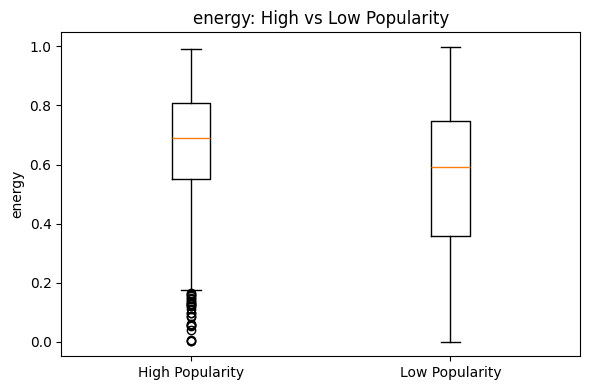

/tmp/ipykernel_37295/1760590007.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


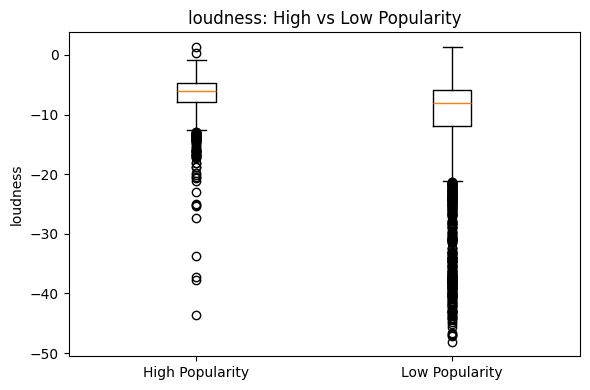

/tmp/ipykernel_37295/1760590007.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


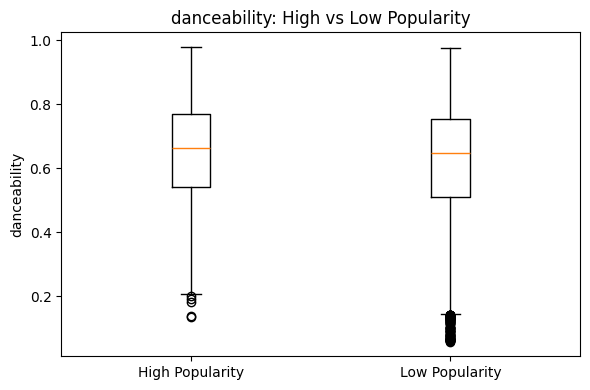

/tmp/ipykernel_37295/1760590007.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


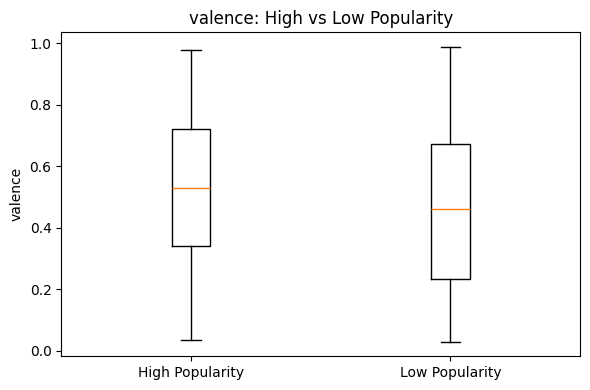

/tmp/ipykernel_37295/1760590007.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


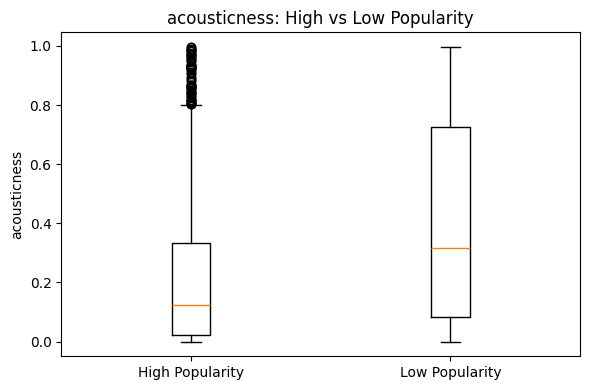

/tmp/ipykernel_37295/1760590007.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


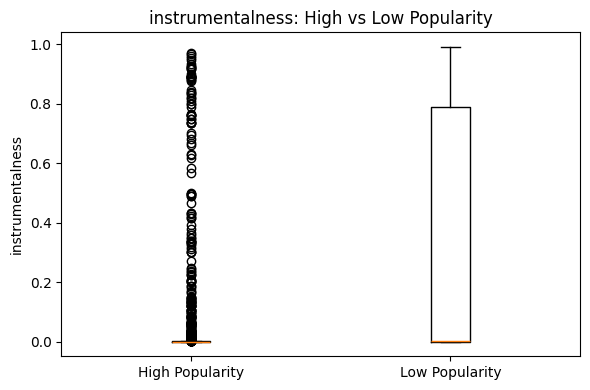

In [9]:
for feature in features:
    plt.figure(figsize=(6, 4))
    plt.boxplot(
        [high[feature].dropna(), low[feature].dropna()],
        labels=["High Popularity", "Low Popularity"]
    )
    plt.title(f"{feature}: High vs Low Popularity")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

## Hypothesis-by-Hypothesis Interpretation

The code cell below translates the statistical output into direct conclusions for each hypothesis.


In [10]:
alpha = 0.05

hypothesis_map = {
    "H1": ["energy", "loudness"],
    "H2": ["danceability", "valence"],
    "H3": ["acousticness", "instrumentalness"]
}

for h_name, h_features in hypothesis_map.items():
    print("=" * 70)
    print(h_name)
    print("=" * 70)
    for feature in h_features:
        row = results_df[results_df["feature"] == feature].iloc[0]
        direction = "higher" if row["mean_diff"] > 0 else "lower"
        decision = "REJECT H0" if row["reject_H0_bonferroni"] else "FAIL TO REJECT H0"

        print(f"\nFeature: {feature}")
        print(f"High mean: {row['high_mean']:.4f}")
        print(f"Low mean : {row['low_mean']:.4f}")
        print(f"Difference (High - Low): {row['mean_diff']:.4f}")
        print(f"95% CI: [{row['ci_low']:.4f}, {row['ci_high']:.4f}]")
        print(f"p-value: {row['p_value']:.6g}")
        print(f"Bonferroni-adjusted p-value: {row['bonferroni_p']:.6g}")
        print(f"Cohen's d: {row['cohen_d']:.4f} ({row['effect_size_interpretation']})")
        print(f"Interpretation: High-popularity songs have {direction} {feature} values.")
        print(f"Decision: {decision}")

H1

Feature: energy
High mean: 0.6672
Low mean : 0.5435
Difference (High - Low): 0.1237
95% CI: [0.1109, 0.1365]
p-value: 1.68349e-77
Bonferroni-adjusted p-value: 1.01009e-76
Cohen's d: 0.5173 (medium)
Interpretation: High-popularity songs have higher energy values.
Decision: REJECT H0

Feature: loudness
High mean: -6.7041
Low mean : -10.6638
Difference (High - Low): 3.9597
95% CI: [3.6321, 4.2873]
p-value: 3.07416e-117
Bonferroni-adjusted p-value: 1.84449e-116
Cohen's d: 0.5759 (medium)
Interpretation: High-popularity songs have higher loudness values.
Decision: REJECT H0
H2

Feature: danceability
High mean: 0.6504
Low mean : 0.6073
Difference (High - Low): 0.0431
95% CI: [0.0328, 0.0534]
p-value: 2.82375e-16
Bonferroni-adjusted p-value: 1.69425e-15
Cohen's d: 0.2309 (small)
Interpretation: High-popularity songs have higher danceability values.
Decision: REJECT H0

Feature: valence
High mean: 0.5257
Low mean : 0.4584
Difference (High - Low): 0.0673
95% CI: [0.0527, 0.0819]
p-value: 2.

## Overall Conclusion

If the expected results are observed, the conclusions should be stated in a short academic style:

- **H1 is supported** if high-popularity songs are significantly more energetic and louder.
- **H2 is supported** if high-popularity songs are significantly more danceable and higher in valence.
- **H3 is supported** if high-popularity songs are significantly less acoustic and less instrumental.
- The null hypothesis is rejected for the features where the corrected p-value is below 0.05.

These findings can then be carried into the machine learning stage, where the same features can be used as candidate predictors of popularity group.


In [11]:
supported_hypotheses = []

for h_name, h_features in hypothesis_map.items():
    all_supported = True
    for feature in h_features:
        row = results_df[results_df["feature"] == feature].iloc[0]

        if h_name in ["H1", "H2"]:
            direction_ok = row["mean_diff"] > 0
        else:  # H3 expects lower values in high-popularity songs
            direction_ok = row["mean_diff"] < 0

        significant_ok = row["reject_H0_bonferroni"]

        if not (direction_ok and significant_ok):
            all_supported = False

    if all_supported:
        supported_hypotheses.append(h_name)

print("Supported hypotheses:", supported_hypotheses if supported_hypotheses else "None")

print("\nFinal summary:")
for _, row in results_df.iterrows():
    significance_text = "significant" if row["reject_H0_bonferroni"] else "not significant"
    direction_text = "higher" if row["mean_diff"] > 0 else "lower"
    print(
        f"- {row['feature']}: high-popularity songs are {direction_text} on average "
        f"({significance_text}, corrected p = {row['bonferroni_p']:.6g})."
    )

Supported hypotheses: ['H1', 'H2', 'H3']

Final summary:
- instrumentalness: high-popularity songs are lower on average (significant, corrected p = 3.76992e-186).
- loudness: high-popularity songs are higher on average (significant, corrected p = 1.84449e-116).
- acousticness: high-popularity songs are lower on average (significant, corrected p = 1.37328e-95).
- energy: high-popularity songs are higher on average (significant, corrected p = 1.01009e-76).
- valence: high-popularity songs are higher on average (significant, corrected p = 1.65943e-18).
- danceability: high-popularity songs are higher on average (significant, corrected p = 1.69425e-15).


## Optional Extension

Short extra section testing exploratory features such as:

- `tempo`
- `liveness`
- `speechiness`

These are not necessary for the core hypotheses, but they can be mentioned as additional findings.


In [12]:
extra_features = ["tempo", "liveness", "speechiness"]

extra_results = []
for feature in extra_features:
    result = welch_test_with_effect_size(high[feature], low[feature])
    result["feature"] = feature
    extra_results.append(result)

extra_df = pd.DataFrame(extra_results)
extra_df["bonferroni_p"] = (extra_df["p_value"] * len(extra_features)).clip(upper=1.0)
extra_df["reject_H0_0_05"] = extra_df["p_value"] < 0.05
extra_df[["feature", "high_mean", "low_mean", "mean_diff", "p_value", "bonferroni_p", "cohen_d", "reject_H0_0_05"]]

,feature,high_mean,low_mean,mean_diff,p_value,bonferroni_p,cohen_d,reject_H0_0_05
0,tempo,121.070938,116.766884,4.304053,3.100367e-07,9.301101e-07,0.151329,True
1,liveness,0.171579,0.165487,0.006092,1.042721e-01,3.128162e-01,0.048966,False
2,speechiness,0.100926,0.102174,-0.001248,6.807401e-01,1.000000e+00,-0.012348,False


## Short Report Paragraph


> Welch’s t-tests were conducted to compare high-popularity and low-popularity Spotify songs across six selected audio features: energy, loudness, danceability, valence, acousticness, and instrumentalness. The results showed statistically significant differences for all six features. High-popularity songs were found to be more energetic, louder, more danceable, and higher in valence, while being less acoustic and less instrumental on average. These results support the proposed hypotheses and suggest that popular songs tend to be more production-driven, rhythm-oriented, and less acoustically or instrumentally dominated.
